In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import Delaunay
import csv

In [3]:
def write_graph_to_csv(G, filename = 'graph.csv', weight = 'length'):
    # Open a CSV file in write mode
    with open('/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/'+filename, 
              'w', newline='') as csvfile:
        # Create a CSV writer object
        csvwriter = csv.writer(csvfile)
    
        # Write the header row (optional)
        csvwriter.writerow(['vertex1', 'vertex2', 'edge_weight'])
    
        # Write edges and their weights to the CSV file
        for u, v, w in G.edges(data=weight):
            csvwriter.writerow([u, v, w])
            
    print('Graph has been written to '+filename)

def write_positions_to_file(pos: dict, path:str):
    with open('/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/'+path, 'w') as csvfile:
        # Create a CSV writer object
        csvwriter = csv.writer(csvfile)
    
        # Write the header row (optional)
        csvwriter.writerow(['vertex1', 'x', 'y'])
    
        # Write edges and their weights to the CSV file
        for i, xy in pos.items():
            csvwriter.writerow([i, xy[0], xy[1]])

# Create and save  DELAUNAY + RING ROAD

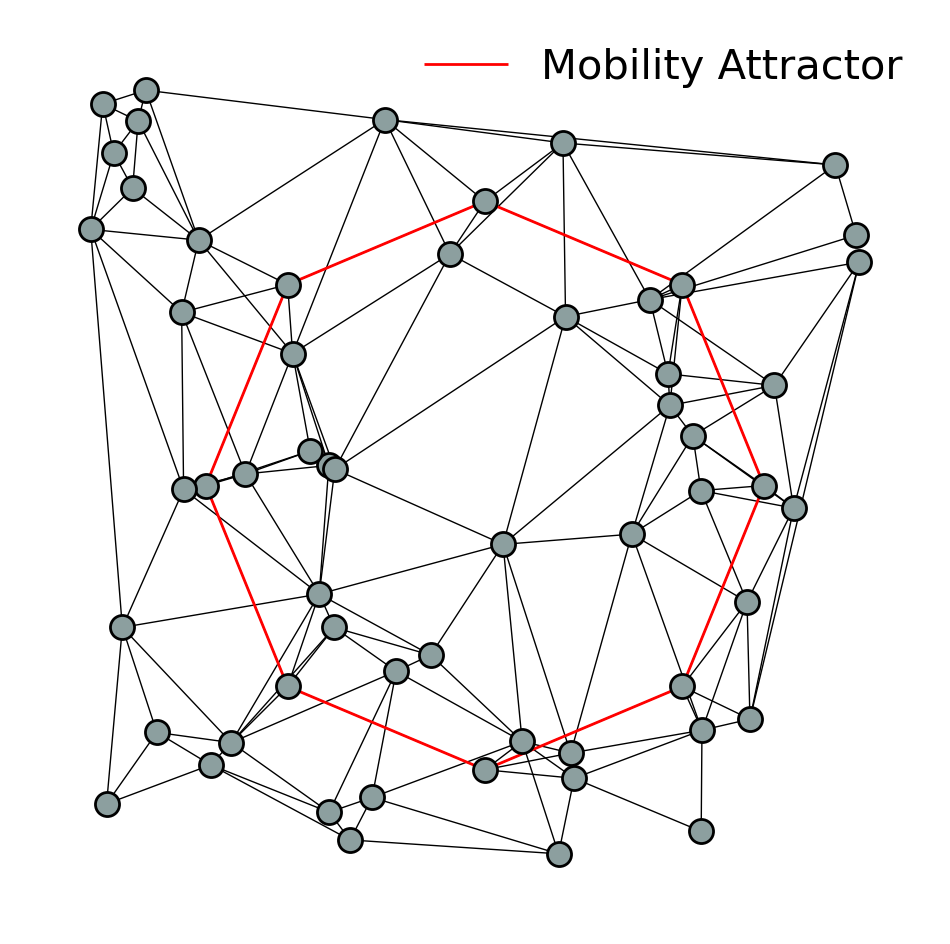

In [61]:
speed_ratio = 2
np.random.seed(42)  # For reproducibility
# totit = 125
totit = 1

for it in range(totit):
        
    # x,y coords of points
    nodes_cl2 = 50
    clust_2 = np.random.uniform(-1, 1, size=(nodes_cl2, 2))

    # for each Delaunay triangle
    delaunay = nx.Graph()
    n_ls = list(range(0, nodes_cl2))
    delaunay.add_nodes_from(n_ls)

    # make a graph based on the Delaunay triangulation edges

    # dictionary of node:position
    pos_cl_2 = dict(zip(range(len(clust_2)), clust_2))
    nx.set_node_attributes(delaunay, pos_cl_2, name='pos')

    tri2 = Delaunay(list(pos_cl_2.values()))

    for path in tri2.simplices:
        nx.add_path(delaunay, path)


    # CIRCULAR GRAPH

    nnodes_c = 8

    circ_g = nx.circulant_graph(nnodes_c, [1], create_using=None)
    circ_g.add_nodes_from(list(range(nnodes_c)))

    pos_c = nx.circular_layout(circ_g, scale = 0.7, center = (0, 0))

    nx.set_node_attributes(circ_g, pos_c, name='pos')

    #combine graphs

    ring_road = nx.disjoint_union(circ_g, delaunay)

    pos_tot = nx.get_node_attributes(ring_road, 'pos')

    #connect the ring nodes to the 3 closest nodes

    for n in range(0, nnodes_c):
        
        node_pos = pos_tot[n]
        dists = [np.linalg.norm(np.array(pos_tot[k]) - 
                                np.array(node_pos))for k in range(len(ring_road))]
        
        t_nodes = np.argsort(dists)[1:4]
        
        for t in t_nodes:
            ring_road.add_edge(n, t)

    # Set Edge Attributes

    edge_dists = {edge : np.linalg.norm(np.array(pos_tot[edge[1]]) - 
                np.array(pos_tot[edge[0]])) for edge in ring_road.edges}


    #change edge of ring to more velocity (30 secs to cross the mean link distance)

    vel = np.mean(np.array(list(edge_dists.values())))/30

    edge_weights = {k : val/vel for k, val in edge_dists.items()}

    nx.set_edge_attributes(ring_road, edge_weights, name = 'time')

    ring_edges = []

    for n in range(0, nnodes_c):
        if n < nnodes_c-1:
            ring_road[n][n+1]['time']/= speed_ratio
            ring_edges.append((n, n+1))
        else:
            ring_road[0][n]['time']/= speed_ratio
            ring_edges.append((0, n))
            
    plt.figure(figsize = (12,12))

    nx.draw_networkx(ring_road, pos = pos_tot, with_labels = False, 
                     node_size = 300, node_color = '#8C9F9F' , linewidths = 2, 
                     edgecolors = 'black')

    nx.draw_networkx_edges(ring_road, pos = pos_tot, edgelist=ring_edges, 
                        edge_color= 'r', node_size=300, width = 2, label = 'Mobility Attractor')
    plt.legend(fontsize = 30, frameon = False)
    plt.axis('off')
    plt.savefig(f'./figs/ring_road_vx{int(speed_ratio)}.png', dpi=300)
    plt.show()

    # write_graph_to_csv(ring_road, f'ring_roads/vx{int(speed_ratio)}/graph_variations/ring'\
    #                 +str(it)+'.csv', weight='time')
    # write_positions_to_file(pos_tot,f'ring_roads/vx{int(speed_ratio)}/node_pos/pos_ring'\
    #                         +str(it)+'.csv')

# Create Star + Delaunay

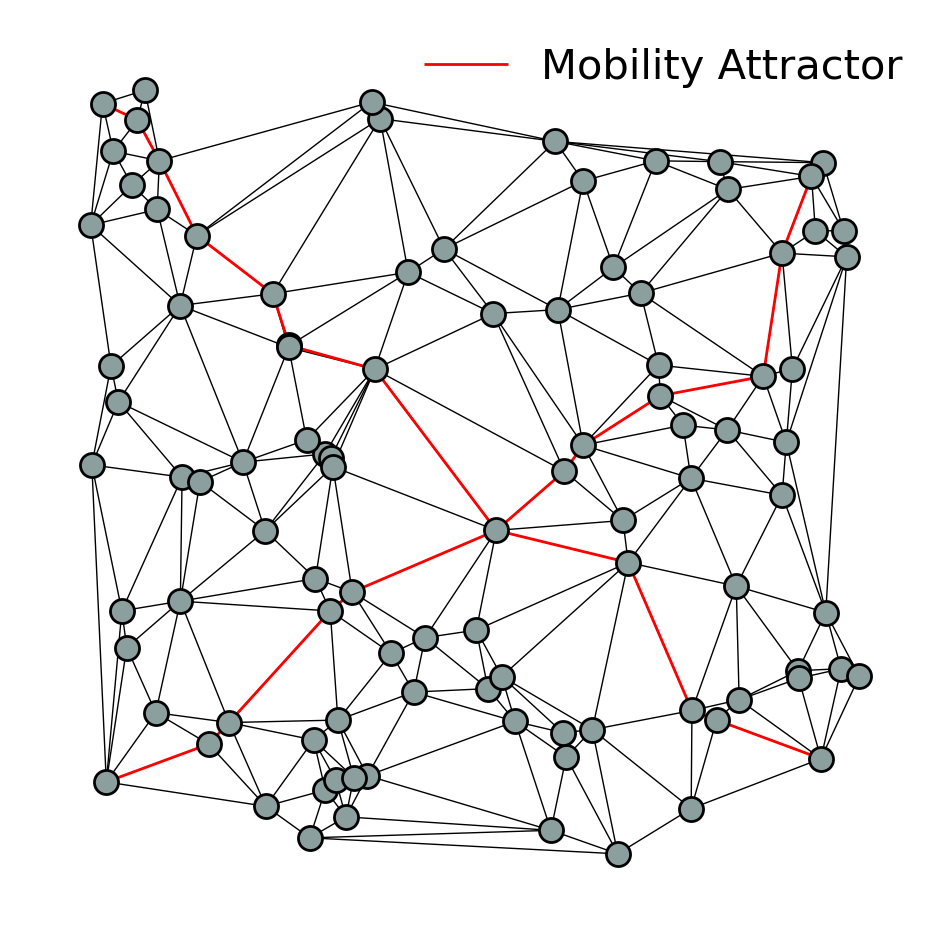

In [62]:
speed_ratio = 2
np.random.seed(42)  # For reproducibility
totit = 1
for it in range(totit):
    
    # x,y coords of points
    nodes_cl2 = 100
    clust_2 = np.random.uniform(-1, 1, size=(nodes_cl2, 2))

    # for each Delaunay triangle
    delaunay = nx.Graph()
    n_ls = list(range(0, nodes_cl2))
    delaunay.add_nodes_from(n_ls)

    # make a graph based on the Delaunay triangulation edges

    # dictionary of node:position
    pos_cl_2 = dict(zip(range(len(clust_2)), clust_2))
    nx.set_node_attributes(delaunay, pos_cl_2, name='pos')

    tri2 = Delaunay(list(pos_cl_2.values()))

    for path in tri2.simplices:
        nx.add_path(delaunay, path)


    # Star GRAPH

    extreme_pos = [(1, 1), (1, -1), (-1, -1), (-1, 1)]

    # take the closest node to each extreme position
    extreme_nodes = []
    for pos in extreme_pos:
        dists = [np.linalg.norm(np.array(pos_cl_2[k]) - 
                                np.array(pos)) for k in range(len(delaunay))]
        
        closest_node = np.argmin(dists)
        extreme_nodes.append(closest_node)
    
    # find the shortest path from each extreme node to the central node
        
    central_node = np.argmin([np.linalg.norm(np.array(pos_cl_2[k])) for k in range(len(delaunay))])

    edge_dists = {edge : np.linalg.norm(np.array(pos_cl_2[edge[1]]) - 
                np.array(pos_cl_2[edge[0]])) for edge in delaunay.edges}
    
    nx.set_edge_attributes(delaunay, edge_dists, name = 'length')

    paths = [nx.shortest_path(delaunay, source = en, target = central_node, weight='length') for en in extreme_nodes]

    # make edge list of the links in the star

    star_edges = []
    for path in paths:
        star_edges += [(path[i], path[i+1]) for i in range(len(path)-1)]

    star_edges = list(set(star_edges))
        

    #change edge of star to more velocity (30 secs to cross the mean link distance)

    vel = 0.01
    edge_weights = {k : val/(speed_ratio*vel) if k in star_edges else val/vel for k, val in edge_dists.items()}

    nx.set_edge_attributes(delaunay, edge_weights, name = 'time')
    
    plt.figure(figsize = (12,12))
    nx.draw_networkx(delaunay, pos = pos_cl_2, with_labels = False, 
                        node_size = 300, node_color = '#8C9F9F' , linewidths = 2, 
                        edgecolors = 'black')
    
    nx.draw_networkx_edges(delaunay, pos = pos_cl_2, edgelist=star_edges, 
                        edge_color= 'r', node_size=300, width = 2, label = 'Mobility Attractor')
    plt.legend(fontsize = 30, frameon = False)
    plt.axis('off')
    plt.savefig(f'./figs/star_road_vx{int(speed_ratio)}.png', dpi=300)
    plt.show()
    # write_graph_to_csv(delaunay, f'star_roads/vx{int(speed_ratio)}/graph_variations/ring'\
    #                 +str(it)+'.csv', weight='time')
    # write_positions_to_file(pos_cl_2,f'star_roads/vx{int(speed_ratio)}/node_pos/pos_ring'\
    #                         +str(it)+'.csv')

## Lattice + Delaunay

In [64]:
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from scipy.spatial import KDTree
import networkx as nx
# import scipy.io as sio  # keep if you really need MATLAB export
# import image2net as i2n # unused here

# -------------------------------------------------------------------
# Parameters
# -------------------------------------------------------------------
seed = 42
speed_ratio = 2
np.random.seed(seed)
max_dist_edge = 500
min_dist_edge = 20
max_degree = 8
n = 100
m = round(n * 1.6)
p = 8
road_speed_central_cluster = 8
road_speed_lattice = speed_ratio*road_speed_central_cluster

#Generate the lattice graph
grid_extent = (0.0, 2000.0)
line_count = 2  # two bars in each direction to resemble a hashtag
q = line_count * (2*p -line_count)  # number of nodes in the lattice

# evenly sample points along each bar; intersections fall on a common grid
grid_coords = np.linspace(grid_extent[0], grid_extent[1], p)
if line_count >= p:
    raise ValueError("line_count must be less than the number of grid samples `p`.")
line_indices = np.linspace(int(p/(line_count+1)), int(p*line_count/(line_count+1)), line_count, dtype=int)  # keep bars away from outer boundary
vertical_levels = grid_coords[line_indices]
horizontal_levels = grid_coords[line_indices]

tot_graphs = 1

for it in range(tot_graphs):
    # -------------------------------------------------------------------
    # Generate underlying lattice graph
    # -------------------------------------------------------------------

    node_lookup = {}
    lattice_nodes = []
    lattice_edges = []

    # helper to create/reuse a node at coordinate
    def get_or_create_uid(coord):
        uid = node_lookup.get(coord)
        if uid is None:
            uid = len(node_lookup)
            node_lookup[coord] = uid
            lattice_nodes.append({'uid': uid, 'x': coord[0], 'y': coord[1]})
        return uid

    # build horizontal bars
    for y in horizontal_levels:
        prev_uid = None
        prev_coord = None
        for x in grid_coords:
            coord = (float(x), float(y))
            uid = get_or_create_uid(coord)
            if prev_uid is not None:
                length = np.hypot(coord[0] - prev_coord[0], coord[1] - prev_coord[1])
                lattice_edges.append({'i': prev_uid, 'j': uid, 'len': length, 'speed': road_speed_lattice})
            prev_uid = uid
            prev_coord = coord

    # build vertical bars
    for x in vertical_levels:
        prev_uid = None
        prev_coord = None
        for y in grid_coords:
            coord = (float(x), float(y))
            uid = get_or_create_uid(coord)
            if prev_uid is not None:
                length = np.hypot(coord[0] - prev_coord[0], coord[1] - prev_coord[1])
                lattice_edges.append({'i': prev_uid, 'j': uid, 'len': length, 'speed': road_speed_lattice})
            prev_uid = uid
            prev_coord = coord

    lattice_nodes_df = pd.DataFrame(lattice_nodes)
    lattice_edge_list = pd.DataFrame(lattice_edges)

    edge_stubs = pd.concat([lattice_edge_list.i, lattice_edge_list.j])
    degree_lattice = edge_stubs.astype(int).value_counts().rename('degree')
    degree_lattice = degree_lattice.reset_index().rename(columns={'index': 'uid'})

    #ax = utils.plot_graph(lattice_nodes_df, lattice_edge_list, ax=None)
    #plt.show()

    # -------------------------------------------------------------------
    # Build central cluster network
    # -------------------------------------------------------------------

    #generate the random points
    xn = np.round(np.random.normal(loc=1000, scale=290, size=n - q), 2)
    yn = np.round(np.random.normal(loc=1000, scale=290, size=n - q), 2)

    central_cluster_node_uids = np.arange(len(xn))
    central_cluster_nodes_df = pd.DataFrame({'uid':central_cluster_node_uids, 'x': xn, 'y': yn})

    #Do the delaunay only for the random points
    points = np.vstack((xn, yn)).T
    tri = Delaunay(points)
    edges = []
    lengths = []
    # Create edges and lengths lists

    for simplex in tri.simplices:
        if [simplex[0],simplex[1]] not in edges and [simplex[1],simplex[0]] not in edges:
            edges.append([simplex[0], simplex[1]])
            lengths.append(np.linalg.norm(points[simplex[0]] - points[simplex[1]]))


        if [simplex[1],simplex[2]] not in edges and [simplex[2],simplex[1]] not in edges:
            edges.append([simplex[1], simplex[2]])
            lengths.append(np.linalg.norm(points[simplex[1]] - points[simplex[2]])) 

        if [simplex[2],simplex[0]] not in edges and [simplex[0],simplex[2]] not in edges:
            edges.append([simplex[2], simplex[0]])
            lengths.append(np.linalg.norm(points[simplex[2]] - points[simplex[0]]))


    edges = np.array(edges)
    lengths = np.array(lengths)
    central_cluster_edges = pd.DataFrame({'i': central_cluster_nodes_df.uid[edges[:, 0]].astype(int).tolist(), 
                                        'j': central_cluster_nodes_df.uid[edges[:, 1]].astype(int).tolist(), 
                                        'len': lengths.tolist()})
    # filter & sample edges
    central_cluster_edges = central_cluster_edges.loc[(central_cluster_edges.len > min_dist_edge) & (central_cluster_edges.len <= max_dist_edge)]
    #central_cluster_edges = central_cluster_edges.sample(m, weights=central_cluster_edges['len'])

    # remove high-degree nodes
    edge_stubs = pd.concat([central_cluster_edges.i, central_cluster_edges.j])
    degree_central_cluster = edge_stubs.astype(int).value_counts().rename('degree')
    degree_central_cluster = degree_central_cluster.reset_index().rename(columns={'index': 'uid'})
    nodes_with_empty_degree = central_cluster_nodes_df[~central_cluster_nodes_df.uid.isin(degree_central_cluster.uid)].uid
    new_rows = {'uid':nodes_with_empty_degree,'degree':np.zeros(len(nodes_with_empty_degree)).tolist()}
    degree_central_cluster = pd.concat([degree_central_cluster,pd.DataFrame(new_rows)],ignore_index=True)

    #remove nodes with too much degree
    bad_nodes = degree_central_cluster[degree_central_cluster.degree > max_degree].uid.astype(int).to_list()

    for k in bad_nodes:
        bad_edges = central_cluster_edges.loc[(central_cluster_edges.i == k) | (central_cluster_edges.j == k)]
        deg = degree_central_cluster[degree_central_cluster.uid == k].degree.tolist()[0]

        #remove degree-max_deg to fall with the degree limit
        nedges_rem = int(1+deg-max_degree)
        edges_to_remove = bad_edges.sample(nedges_rem)

        #check that the degree of the other node is not going below 0
        for idx, row in edges_to_remove.iterrows():
            other_node = row.j if row.i == k else row.i
            other_node_degree = degree_central_cluster[degree_central_cluster.uid == other_node].degree.tolist()[0]
            if other_node_degree <= 1:
                #find another edge to remove
                alternative_edges = bad_edges.drop(idx)
                if len(alternative_edges) > 0:
                    new_edge_to_remove = alternative_edges.sample(1)
                    edges_to_remove = pd.concat([edges_to_remove.drop(idx), new_edge_to_remove])
                else:
                    edges_to_remove = edges_to_remove.drop(idx)
        
        central_cluster_edges = central_cluster_edges.drop(edges_to_remove.index)

        # update the degree
        edge_stubs = pd.concat([central_cluster_edges.i, central_cluster_edges.j])
        degree_central_cluster = edge_stubs.astype(int).value_counts().rename('degree')
        degree_central_cluster = degree_central_cluster.reset_index().rename(columns={'index': 'uid'})
        nodes_with_empty_degree = central_cluster_nodes_df[~central_cluster_nodes_df.uid.isin(degree_central_cluster.uid)].uid
        new_rows = {'uid':nodes_with_empty_degree,'degree':np.zeros(len(nodes_with_empty_degree)).tolist()}
        degree_central_cluster = pd.concat([degree_central_cluster,pd.DataFrame(new_rows)],ignore_index=True)

    # central_cluster_edges = central_cluster_edges.loc[~(central_cluster_edges.i.isin(bad_nodes)) & ~(central_cluster_edges.j.isin(bad_nodes))]
    central_cluster_edges = central_cluster_edges.assign(speed=road_speed_central_cluster)  # m/s
    central_cluster_edges = central_cluster_edges.reset_index(drop=True)

    # -------------------------------------------------------------------
    # Joint the underlying lattice
    # -------------------------------------------------------------------
    #this will be the final netowork
    join_network_edges = central_cluster_edges.copy(deep=True)
    join_network_nodes = central_cluster_nodes_df.copy(deep=True)

    max_node_id = max(central_cluster_nodes_df.uid)
    #combine info from both networks
    lattice_nodes_df.uid = lattice_nodes_df.uid + (max_node_id+1)
    lattice_edge_list.i = lattice_edge_list.i + (max_node_id+1)
    lattice_edge_list.j = lattice_edge_list.j + (max_node_id+1)
    degree_lattice_corrected = degree_lattice.copy(deep=True)
    degree_lattice_corrected.uid = degree_lattice_corrected.uid + (max_node_id+1)

    lattice_point_set = np.column_stack((lattice_nodes_df.x, lattice_nodes_df.y)) 

    #set a metric tree for queries, this facilitates the operation without loops
    nodes_locations = np.column_stack((central_cluster_nodes_df.x, central_cluster_nodes_df.y)) 
    tree = KDTree(nodes_locations)
    distances, indices = tree.query(lattice_point_set)
    #add the corresponding edges to the edge list and nodes to the nodes list
    for qi, (d, idx) in enumerate(zip(distances, indices)):
        # query point
        lattice_x, lattice_y = lattice_nodes_df.iloc[qi].x, lattice_nodes_df.iloc[qi].y
        lattice_uid = lattice_nodes_df.iloc[qi].uid.astype(int)
        # matched point from your dataset
        px_i, py_i = central_cluster_nodes_df.iloc[idx].x, central_cluster_nodes_df.iloc[idx].y
        central_cluster_uid = central_cluster_nodes_df.iloc[idx].uid.astype(int)

        new_degree_central_cluster = (degree_central_cluster[degree_central_cluster.uid == central_cluster_uid].degree + 1).tolist()[0]
        new_degree_lattice = (degree_lattice_corrected[degree_lattice_corrected.uid == lattice_uid].degree + 1).tolist()[0]
        # add edge if within distance thresholds and degree limits
        if bool(d>=min_dist_edge) & bool(d<=max_dist_edge) & (new_degree_central_cluster<=max_degree) & (new_degree_lattice <=max_degree):
            new_edge = {'i': lattice_uid, 'j': central_cluster_uid, 'len': d, 'speed': road_speed_central_cluster}
            join_network_edges = pd.concat([join_network_edges,pd.DataFrame([new_edge])],ignore_index=True)
            
    join_network_nodes = pd.concat([join_network_nodes,lattice_nodes_df],ignore_index=True)
    join_network_edges = pd.concat([join_network_edges,lattice_edge_list],ignore_index=True)

    # join_network_nodes.to_csv(f'./synthetic_data/Lattice_cluster_network_nodes_seed{seed}.csv',index=False)
    # join_network_edges.to_csv(f'./synthetic_data/Lattice_cluster_network_edges_seed{seed}.csv',index=False)
    # ax = utils.plot_graph(join_network_nodes, join_network_edges, ax=None)
    # plt.show()

    G = nx.from_pandas_edgelist(join_network_edges, source='i', target='j', edge_attr=['len','speed'], create_using=nx.Graph())
    nx.set_edge_attributes(G, {(u, v): data['len']/data['speed'] for u, v, data in G.edges(data=True)}, name='time')
    #remove degree 2 nodes
    # degree_full = pd.Series(dict(G.degree())).rename('degree').reset_index().rename(columns={'index': 'uid'})
    # degree_2_nodes = degree_full[degree_full.degree <= 2].uid.astype(int).to_list()
    # G.remove_nodes_from(degree_2_nodes)
    # join_network_nodes = join_network_nodes[~join_network_nodes.uid.isin(degree_2_nodes)]
    # join_network_edges = nx.to_pandas_edgelist(G)
    if len(G.nodes) != n:
        print(f'Graph {i} has {len(G.nodes)} nodes instead of {n}. Regenerating...')

    pos = {node:(data['x'], data['y']) for node, data in join_network_nodes.set_index('uid').iterrows()}

    if np.any(np.array(list(pos.values()))<0) or np.any(np.array(list(pos.values()))>2000):
        print(f'Graph {it} has nodes out of bounds.')
        nx.draw_networkx(G, pos=pos, node_size=50, font_size=8, with_labels=False, node_color = '#8C9F9F' ,
                         linewidths = 2, edgecolors = 'black',
                         #edge_color=np.array(list(nx.get_edge_attributes(G,name = 'speed').values()))/max(road_speed_lattice, road_speed_central_cluster), 
                         cmap=plt.cm.viridis, width=2)

        nx.draw_networkx_edges(G, pos = pos, edgelist=lattice_edge_list[["i", "j"]].to_numpy().tolist(), 
                            edge_color= 'r', node_size=50, width = 2, label = 'lattice edges')
        plt.legend()
        plt.show()
        continue

    # write_graph_to_csv(G, f'lattice_roads/vx{int(speed_ratio)}/graph_variations/ring'\
    #                 +str(it)+'.csv', weight='time')
    # write_positions_to_file(pos,f'lattice_roads/vx{int(speed_ratio)}/node_pos/pos_ring'\
    #                         +str(it)+'.csv')

/Users/robertbenassai/anaconda3/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:437: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


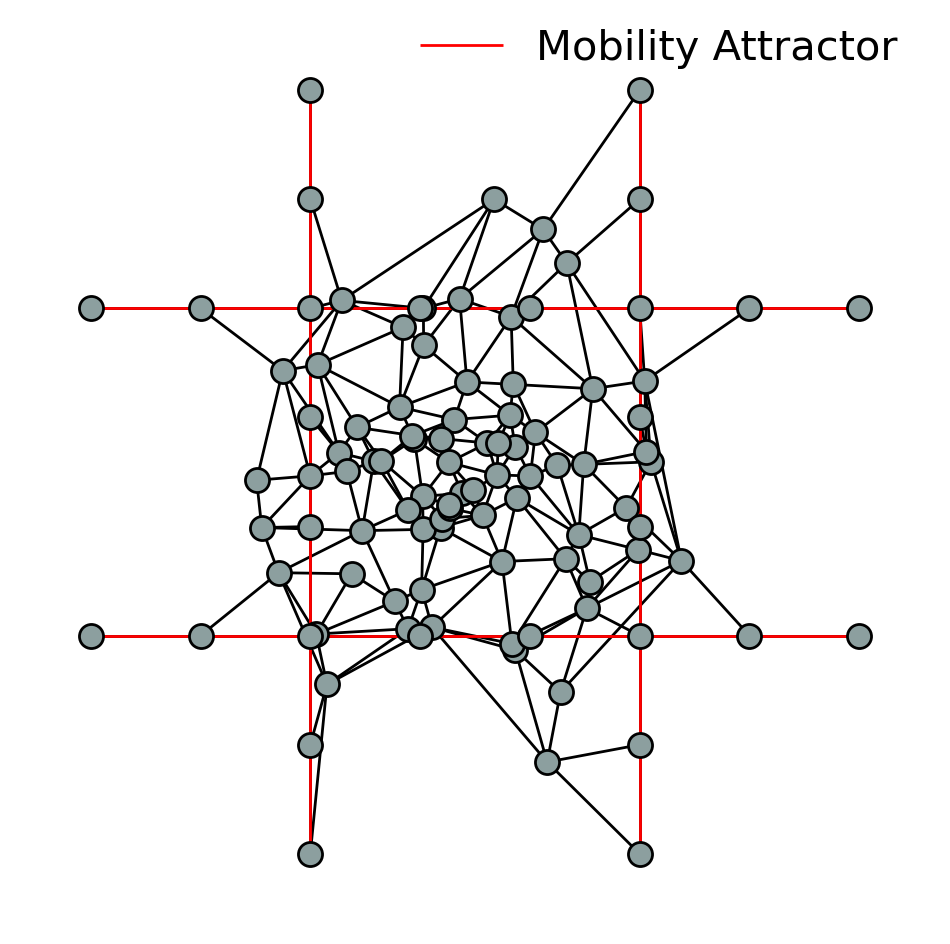

100


In [67]:
plt.figure(figsize = (12,12))
nx.draw_networkx(G, pos=pos, node_size=300, font_size=8, with_labels=False, node_color = '#8C9F9F' ,
                    linewidths = 2, edgecolors = 'black',
                    #edge_color=np.array(list(nx.get_edge_attributes(G,name = 'speed').values()))/max(road_speed_lattice, road_speed_central_cluster), 
                    cmap=plt.cm.viridis, width=2)

nx.draw_networkx_edges(G, pos = pos, edgelist=lattice_edge_list[["i", "j"]].to_numpy().tolist(), 
                    edge_color= 'r', node_size=50, width = 2, label = 'Mobility Attractor')
plt.legend(fontsize = 30, loc = 'upper left', bbox_to_anchor=(0.4, 1.02, 0, 0),
           frameon = False)
plt.axis('off')
plt.savefig(f'./figs/lattice_road_vx{int(speed_ratio)}.png', dpi=300)

plt.show()
print(len(G.nodes))